In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch
import wandb
import sys
from pathlib import Path

In [2]:
PROJECT_ROOT = "/share/castor/home/e2406751/Superresolution-TIR"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from scripts.utils.dataset import SRDataset
from scripts.models.edsr import EDSRModule
from scripts.models.swinir import SwinIRModule
from scripts.training.train import campaign_split
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


edsr

In [3]:
api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-ykuym14h:best")
ckpt_dir = artifact.download("/tmp/ckpt")

ckpt_path = next(
    os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")
)

model = EDSRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.
wandb:   1 of 1 files downloaded.  
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of 

[INFO] Loading pretrained weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Matched 68 / 74 layers
upsample.0.weight
upsample.0.bias
upsample.2.weight
upsample.2.bias
conv_last.weight
conv_last.bias
Loaded: /tmp/ckpt/model.ckpt


swin 

In [3]:
api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-6ar1m0el:best")
ckpt_dir = artifact.download("/tmp/ckpt")

ckpt_path = next(os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt"))

model = SwinIRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.


wandb: Downloading large artifact 'model-6ar1m0el:best', 64.73MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.1 (30.5MB/s)
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full contr

[INFO] Successfully replaced conv_last with 1-ch output.
[INFO] Loading pretrained SwinIR weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_Large_x4.pth
[INFO] Loaded 542/550 layers
Loaded: /tmp/ckpt/model.ckpt


In [4]:
with open("data/full_metadata.json") as f:
    metadata = pd.DataFrame(json.load(f))

# Match evaluate.py strategy to get test set metadata
# _, _, test_df = campaign_split(metadata, "PDR")
# test_df = test_df.reset_index(drop=True)

# for random
test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)

print("Test patches:", len(test_df))

Test patches: 8


In [ ]:
ds = SRDataset(
    test_df,
    mean=model.hparams.mean,
    std=model.hparams.std
    # patch_size=48,
    # is_train=False
)

edsr

SR PSNR (valid px): 29.951 dB
SR MAE  (valid px): 1.833 C
SR RMSE (valid px): 2.544 C
SR Bias (valid px): +0.049 C


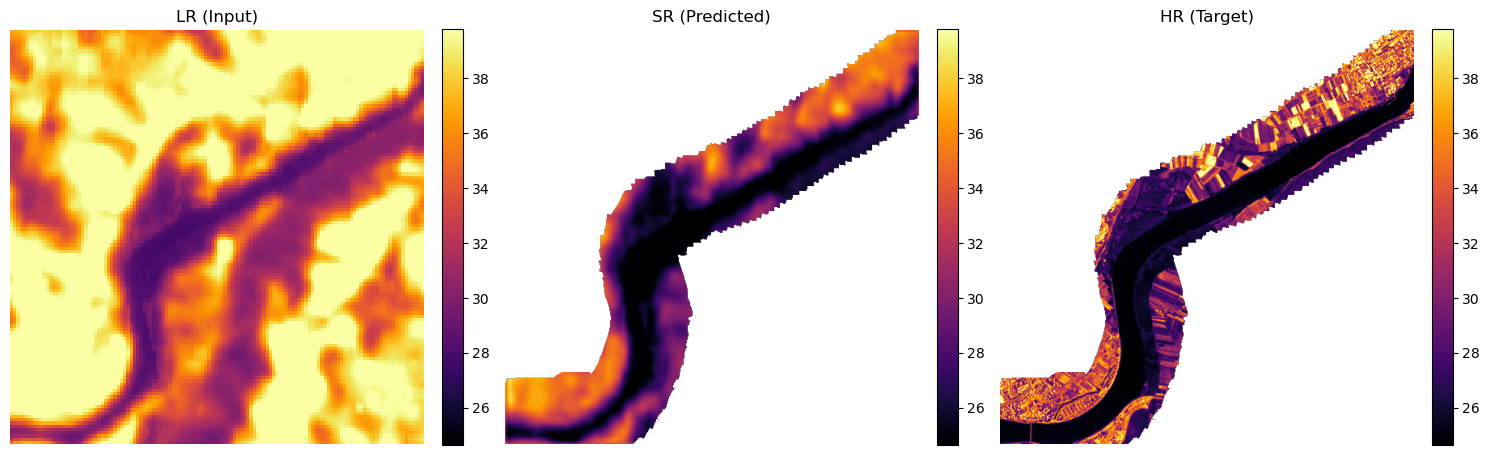

In [10]:
idx = 5 

# 1. Get data and run model
lr_t, hr_t, mask_t = ds[idx]
with torch.no_grad():
    sr_t = model(lr_t.unsqueeze(0).to(device))

# 2. Denormalize to Celsius (Squeeze to 2D: H, W)
sr_np = model.denormalize(sr_t).detach().cpu().numpy().squeeze()
hr_np = model.denormalize(hr_t.unsqueeze(0)).cpu().numpy().squeeze()
lr_np = model.denormalize(lr_t.unsqueeze(0)).cpu().numpy().squeeze()

# 3. Fix the Mask (Ensure it matches SR size: H_sr, W_sr)
# We use [None, None, ...] to safely add Batch/Channel dims for interpolate
mask_4d = mask_t[None, None, :, :] if mask_t.ndim == 2 else mask_t[None, :, :, :]
mask_upsampled = torch.nn.functional.interpolate(
    mask_4d.to(device), size=sr_np.shape, mode='nearest'
).cpu().numpy().squeeze()

mask_bool = mask_upsampled > 0.5

def psnr_on_valid(pred, target, valid_mask, data_range):
    err = pred[valid_mask] - target[valid_mask]
    mse = np.mean(err ** 2)
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def mae_on_valid(pred, target, valid_mask):
    return float(np.mean(np.abs(pred[valid_mask] - target[valid_mask])))

valid = mask_bool
data_range = float(model.DATA_RANGE)

psnr_sr = psnr_on_valid(sr_np, hr_np, valid, data_range)
mae_sr = mae_on_valid(sr_np, hr_np, valid)
bias_sr = float(np.mean((sr_np - hr_np)[valid]))
rmse_sr = float(np.sqrt(np.mean(((sr_np - hr_np)[valid])**2)))

print(f"SR PSNR (valid px): {psnr_sr:.3f} dB")
print(f"SR MAE  (valid px): {mae_sr:.3f} C")
print(f"SR RMSE (valid px): {rmse_sr:.3f} C")
print(f"SR Bias (valid px): {bias_sr:+.3f} C")

# 4. Mask and get display range
sr_final = np.where(mask_bool, sr_np, np.nan)
hr_final = np.where(mask_bool, hr_np, np.nan)

vmin, vmax = np.nanpercentile(hr_final, [2, 98])

# 5. Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
titles = ["LR (Input)", "SR (Predicted)", "HR (Target)"]
images = [lr_np, sr_final, hr_final]

for a, img, t in zip(ax, images, titles):
    im = a.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
    a.set_title(t)
    a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

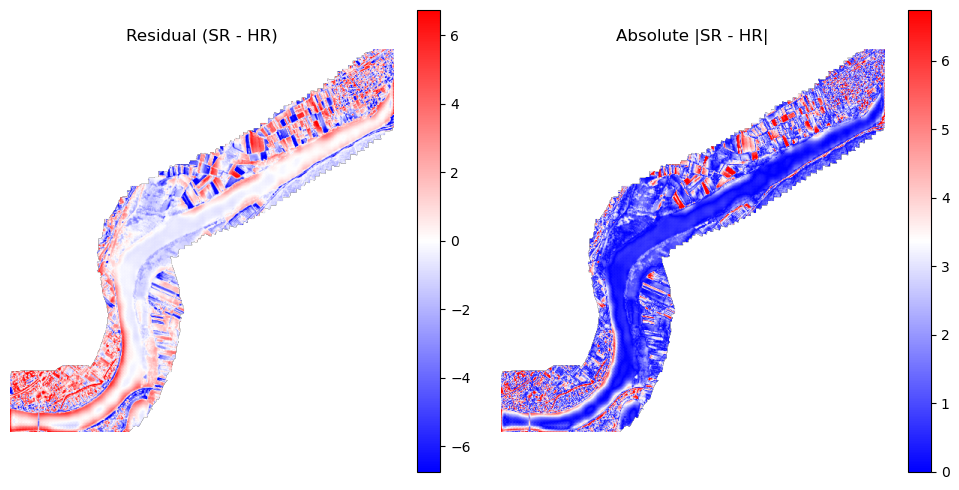

In [8]:
residual = sr_final - hr_final
residual_abs = np.abs(residual)

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(10, 5))

# Signed residual
plt.subplot(1, 2, 1)
plt.title("Residual (SR - HR)")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar()
plt.axis("off")

# Absolute residual
plt.subplot(1, 2, 2)
plt.title("Absolute |SR - HR|")
plt.imshow(residual_abs, cmap="bwr", vmin=0, vmax=v)
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

swinir

In [ ]:
idx = 2 

# 1. Get data and run model
lr_t, hr_t, mask_t = ds[idx]
with torch.no_grad():
    sr_t = model(lr_t.unsqueeze(0).to(device))

# 2. Denormalize to Celsius (Squeeze to 2D: H, W)
sr_np = model.denormalize(sr_t).detach().cpu().numpy().squeeze()
hr_np = model.denormalize(hr_t.unsqueeze(0)).cpu().numpy().squeeze()
lr_np = model.denormalize(lr_t.unsqueeze(0)).cpu().numpy().squeeze()

# 3. Fix the Mask (Ensure it matches SR size: H_sr, W_sr)
# We use [None, None, ...] to safely add Batch/Channel dims for interpolate
mask_4d = mask_t[None, None, :, :] if mask_t.ndim == 2 else mask_t[None, :, :, :]
mask_upsampled = torch.nn.functional.interpolate(
    mask_4d.to(device), size=sr_np.shape, mode='nearest'
).cpu().numpy().squeeze()

mask_bool = mask_upsampled > 0.5

def psnr_on_valid(pred, target, valid_mask, data_range):
    err = pred[valid_mask] - target[valid_mask]
    mse = np.mean(err ** 2)
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def mae_on_valid(pred, target, valid_mask):
    return float(np.mean(np.abs(pred[valid_mask] - target[valid_mask])))

valid = mask_bool
data_range = float(model.DATA_RANGE)

psnr_sr = psnr_on_valid(sr_np, hr_np, valid, data_range)
mae_sr = mae_on_valid(sr_np, hr_np, valid)
bias_sr = float(np.mean((sr_np - hr_np)[valid]))
rmse_sr = float(np.sqrt(np.mean(((sr_np - hr_np)[valid])**2)))

print(f"SR PSNR (valid px): {psnr_sr:.3f} dB")
print(f"SR MAE  (valid px): {mae_sr:.3f} C")
print(f"SR RMSE (valid px): {rmse_sr:.3f} C")
print(f"SR Bias (valid px): {bias_sr:+.3f} C")

# 4. Mask and get display range
sr_final = np.where(mask_bool, sr_np, np.nan)
hr_final = np.where(mask_bool, hr_np, np.nan)

vmin, vmax = np.nanpercentile(hr_final, [2, 98])

# 5. Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
titles = ["LR (Input)", "SR (Predicted)", "HR (Target)"]
images = [lr_np, sr_final, hr_final]

for a, img, t in zip(ax, images, titles):
    im = a.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
    a.set_title(t)
    a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
residual = sr_final - hr_final
residual_abs = np.abs(residual)

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(10, 5))

# Signed residual
plt.subplot(1, 2, 1)
plt.title("Residual (SR - HR)")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar()
plt.axis("off")

# Absolute residual
plt.subplot(1, 2, 2)
plt.title("Absolute |SR - HR|")
plt.imshow(residual_abs, cmap="bwr", vmin=0, vmax=v)
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
import torch.nn.functional as F

def psnr_on_valid(pred, target, valid_mask, data_range):
    err = pred[valid_mask] - target[valid_mask]
    mse = np.mean(err ** 2)
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def mae_on_valid(pred, target, valid_mask):
    return float(np.mean(np.abs(pred[valid_mask] - target[valid_mask])))

# Bicubic upsample LR -> HR size
with torch.no_grad():
    bicubic_t = F.interpolate(
        lr_t.unsqueeze(0).to(device),     # (1,1,h,w)
        size=hr_t.shape[-2:],             # HR shape
        mode="bicubic",
        align_corners=False
    )

# Denormalize to Celsius
bicubic_np = model.denormalize(bicubic_t).cpu().numpy().squeeze()

# Valid mask from your existing pipeline
valid = mask_bool

# Same range as model metrics
data_range = float(model.DATA_RANGE)

# Compare SR vs Bicubic on valid pixels only
psnr_sr = psnr_on_valid(sr_np, hr_np, valid, data_range)
psnr_bi = psnr_on_valid(bicubic_np, hr_np, valid, data_range)
mae_sr = mae_on_valid(sr_np, hr_np, valid)
mae_bi = mae_on_valid(bicubic_np, hr_np, valid)

print(f"PSNR SR      : {psnr_sr:.3f} dB")
print(f"PSNR Bicubic : {psnr_bi:.3f} dB")
print(f"Delta PSNR   : {psnr_sr - psnr_bi:+.3f} dB")
print(f"MAE SR       : {mae_sr:.3f} C")
print(f"MAE Bicubic  : {mae_bi:.3f} C")
print(f"Delta MAE    : {mae_sr - mae_bi:+.3f} C  (negative is better)")

PSNR SR      : 18.763 dB
PSNR Bicubic : 11.554 dB
Delta PSNR   : +7.209 dB
MAE SR       : 1.904 C
MAE Bicubic  : 5.323 C
Delta MAE    : -3.419 C  (negative is better)


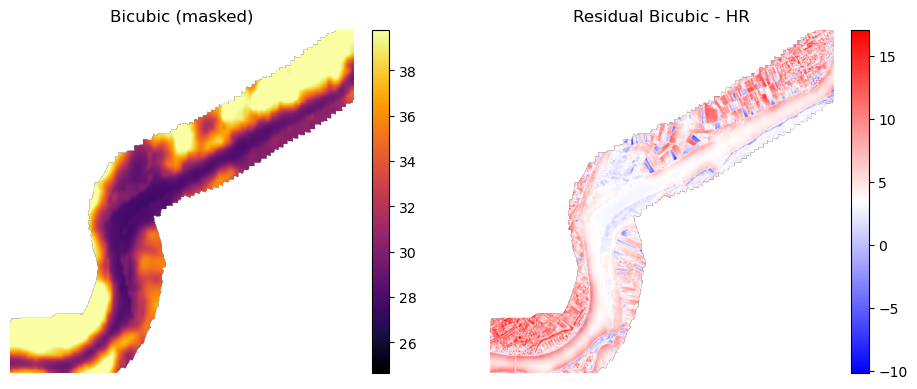

In [34]:
residual_bi = np.where(valid, bicubic_np - hr_np, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(np.where(valid, bicubic_np, np.nan), cmap="inferno", vmin=vmin, vmax=vmax)
ax[0].set_title("Bicubic (masked)")
ax[0].axis("off")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(residual_bi, cmap="bwr")
ax[1].set_title("Residual Bicubic - HR")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

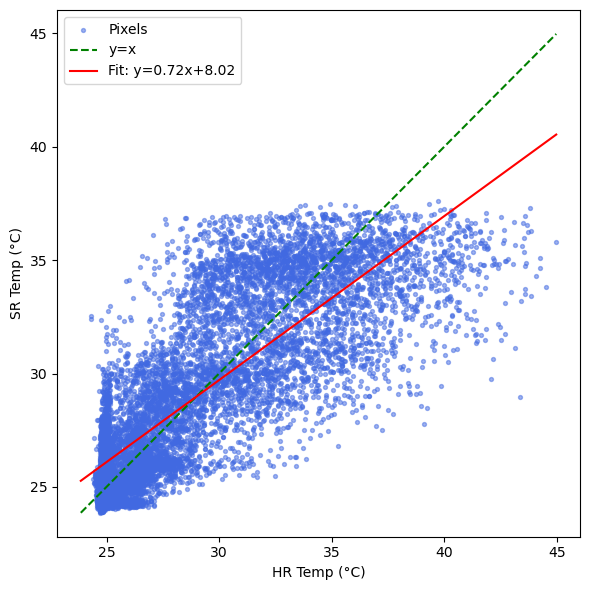

In [21]:
# Flatten valid pixels
hr_valid = hr_final[mask_bool].flatten()
sr_valid = sr_final[mask_bool].flatten()

# Sample pixels for plotting
num_samples = min(len(hr_valid), 10000)
indices = np.random.choice(len(hr_valid), num_samples, replace=False)
hr_sample = hr_valid[indices]
sr_sample = sr_valid[indices]

# Scatter plot
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(hr_sample, sr_sample, s=8, alpha=0.5, color='royalblue', label='Pixels')

# Ideal prediction line
t_min = min(hr_sample.min(), sr_sample.min())
t_max = max(hr_sample.max(), sr_sample.max())
ax.plot([t_min, t_max], [t_min, t_max], 'g--', lw=1.5, label='y=x')

# Regression line
coeffs = np.polyfit(hr_sample, sr_sample, 1)
x_line = np.array([t_min, t_max])
ax.plot(x_line, np.polyval(coeffs, x_line), 'r-', lw=1.5, label=f'Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}')


ax.set_xlabel("HR Temp (°C)")
ax.set_ylabel("SR Temp (°C)")
ax.legend()
plt.tight_layout()
plt.show()

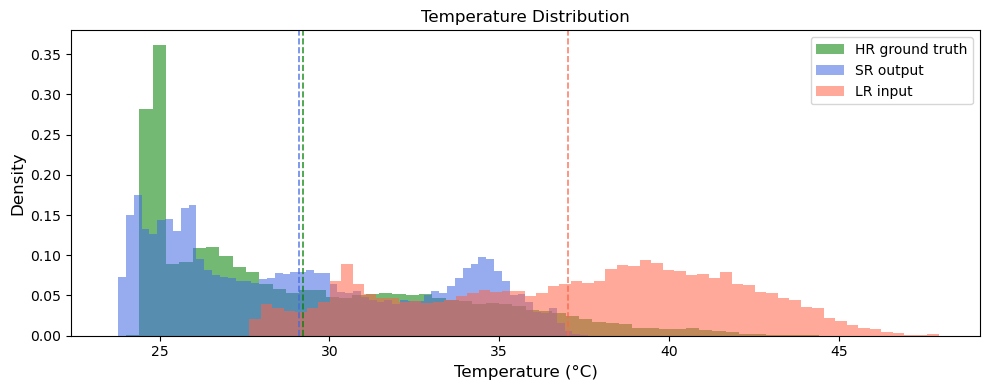

In [15]:
# A blurry model will have SR std << HR std — distribution too narrow
# A good model will have SR std ≈ HR std and similar shape
hr_valid = hr_final[mask_bool].flatten()
sr_valid = sr_final[mask_bool].flatten()
# lr_valid = lr_final[lr_mask].flatten()
lr_valid = lr_np.flatten()  # no masking needed
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hr_valid, bins=60, alpha=0.55, color="green",     label="HR ground truth", density=True)
ax.hist(sr_valid, bins=60, alpha=0.55, color="royalblue", label="SR output",       density=True)
ax.hist(lr_valid, bins=60, alpha=0.55, color="tomato",    label="LR input",        density=True)
 
# Vertical mean lines
for val, color in [(hr_valid.mean(), "green"),
                   (sr_valid.mean(), "royalblue"),
                   (lr_valid.mean(), "tomato")]:
    ax.axvline(val, color=color, linestyle="--", lw=1.2, alpha=0.8)
 
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Temperature Distribution", fontsize=12)
ax.legend(fontsize=10)
 
# Std annotation — key diagnostic for blurriness
# textstr = (f"HR  std: {hr_valid.std():.3f} °C\n"
#            f"SR  std: {sr_valid.std():.3f} °C\n"
#            f"LR  std: {lr_valid.std():.3f} °C")
# ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
#         fontsize=9, va="top", ha="right",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.show()

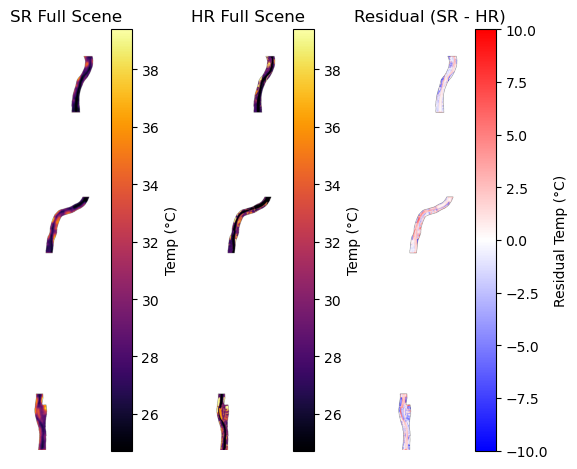

In [16]:
# viz SR and HR full scene
with rasterio.open('/share/home/e2406751/Superresolution-TIR/results/SR_images/SR_DZM_2023.tif') as src:
    nodata = src.nodata
    sr_full = src.read(1).astype(np.float32)

with rasterio.open('/share/home/e2406751/Superresolution-TIR/results/SR_images/HR_reassembled_DZM_2023.tif') as src:
    nodata = src.nodata
    hr_full = src.read(1).astype(np.float32)


#mask nodata regions if needed (assuming nodata is represented by zeros or a specific value)
# nodata_value = -99999  # change if your nodata is different
sr_full_masked = np.where(sr_full == nodata, np.nan, sr_full)
hr_full_masked = np.where(hr_full == nodata, np.nan, hr_full)

residual = sr_full_masked - hr_full_masked


#plt.figure(figsize=(18, 8))
plt.subplot(1, 3, 1)
plt.imshow(sr_full_masked, cmap="inferno", vmin=vmin, vmax=vmax)
plt.title("SR Full Scene", fontsize=12)
plt.axis("off")
plt.colorbar(label="Temp (°C)")

plt.subplot(1, 3, 2)
plt.imshow(hr_full_masked, cmap="inferno", vmin=vmin, vmax=vmax)   
plt.title("HR Full Scene", fontsize=12)
plt.axis("off")
plt.colorbar(label="Temp (°C)")

plt.subplot(1, 3, 3)
plt.imshow(residual, cmap="bwr", vmin=-10, vmax=10)
plt.colorbar(label="Residual Temp (°C)")
plt.title("Residual (SR - HR)", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

SR  range : 33.48 – 37.39 °C
HR  range : 9.06 – 71.19 °C
vmin/vmax : 24.78 / 40.16


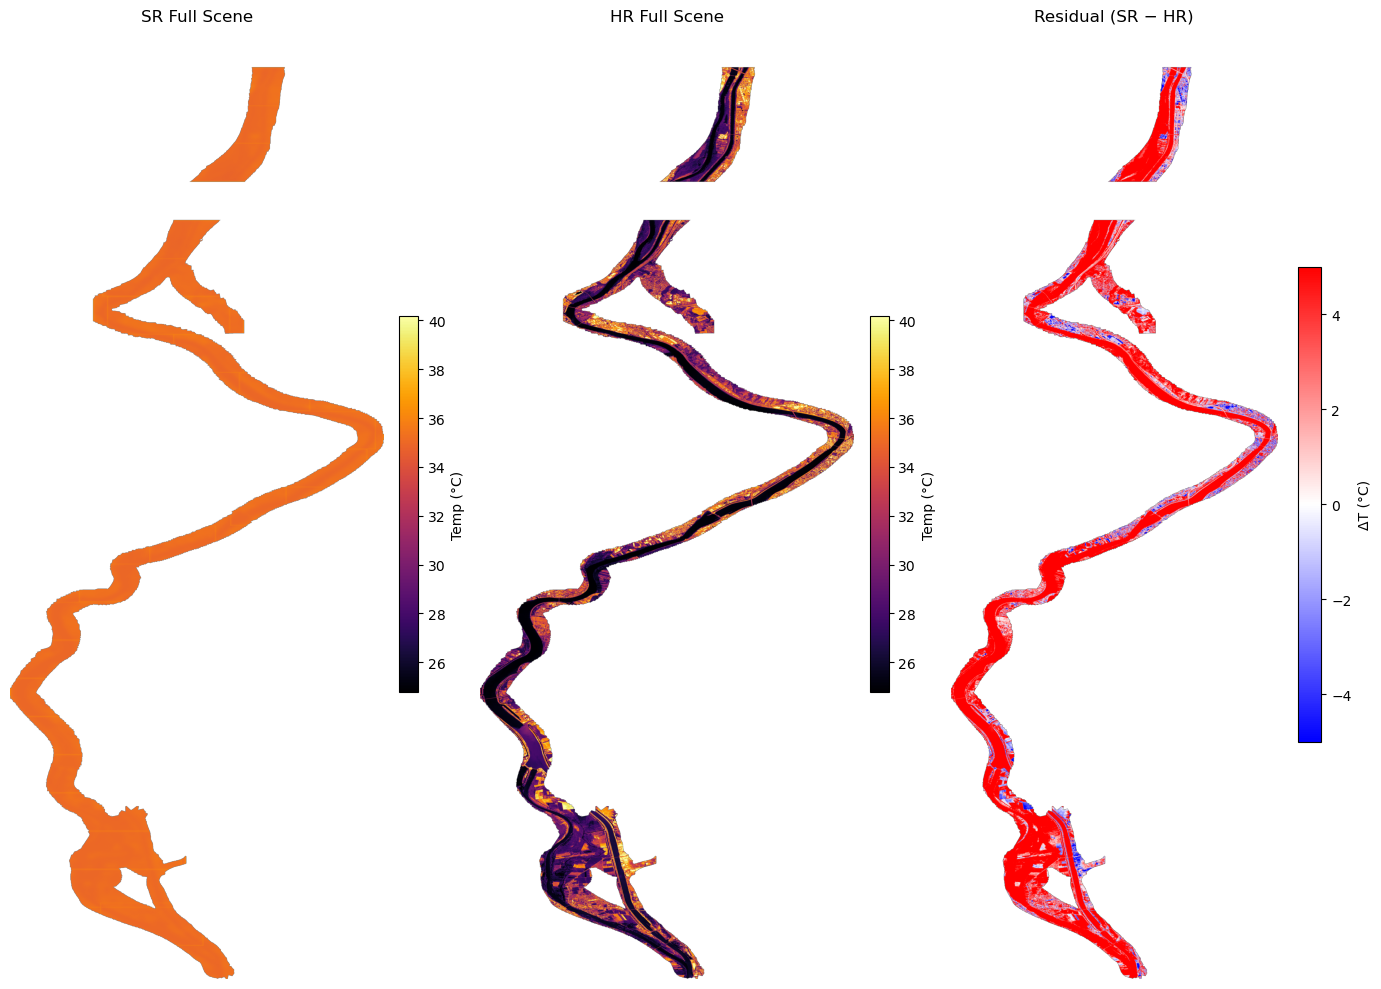

In [9]:
sr_path = "results/SR_images/SR_PDR_2023.tif"
hr_path = "results/SR_images/HR_reassembled_PDR_2023.tif"

with rasterio.open(sr_path) as src:
    sr = src.read(1).astype(np.float32)
    sr_nodata = src.nodata

with rasterio.open(hr_path) as src:
    hr = src.read(1).astype(np.float32)
    hr_nodata = src.nodata

# Mask
sr = np.where(sr == sr_nodata, np.nan, sr)
hr = np.where(hr == hr_nodata, np.nan, hr)
residual = sr - hr

# Stats from valid pixels only
vmin = np.nanpercentile(hr, 2)
vmax = np.nanpercentile(hr, 98)

print(f"SR  range : {np.nanmin(sr):.2f} – {np.nanmax(sr):.2f} °C")
print(f"HR  range : {np.nanmin(hr):.2f} – {np.nanmax(hr):.2f} °C")
print(f"vmin/vmax : {vmin:.2f} / {vmax:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 10))

axes[0].imshow(sr, cmap="inferno", vmin=vmin, vmax=vmax, aspect="auto")
axes[0].set_title("SR Full Scene")
axes[0].axis("off")
plt.colorbar(mappable=axes[0].images[0], ax=axes[0], label="Temp (°C)", fraction=0.046, pad=0.04)

axes[1].imshow(hr, cmap="inferno", vmin=vmin, vmax=vmax, aspect="auto")
axes[1].set_title("HR Full Scene")
axes[1].axis("off")
plt.colorbar(mappable=axes[1].images[0], ax=axes[1], label="Temp (°C)", fraction=0.046, pad=0.04)

im = axes[2].imshow(residual, cmap="bwr", vmin=-5, vmax=5, aspect="auto")
axes[2].set_title("Residual (SR − HR)")
axes[2].axis("off")

plt.colorbar(im, ax=axes[2], label="ΔT (°C)", shrink=0.5)
plt.tight_layout()
plt.show()

SR  range : 23.84 – 40.78 °C
HR  range : 21.82 – 79.43 °C
vmin/vmax : 23.97 / 40.77
Residual limits : -8.22 / 8.22


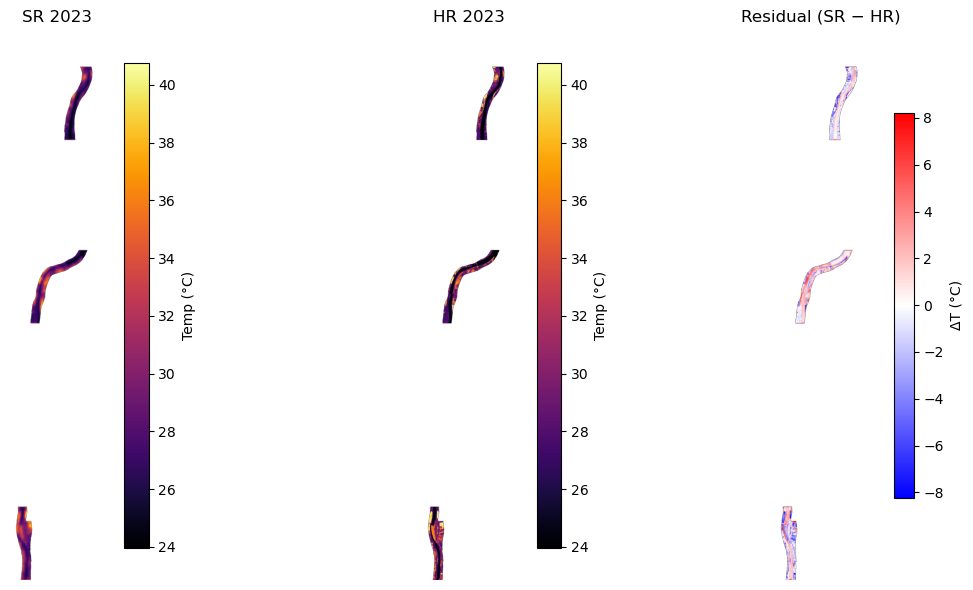

In [17]:
# Paths
sr_path = "results/SR_images/SR_DZM_2023.tif"
hr_path = "results/SR_images/HR_reassembled_DZM_2023.tif"

# Helper function
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
    return np.where(arr == nodata, np.nan, arr)

# Load data
sr = load_raster(sr_path)
hr = load_raster(hr_path)

# Residual (safe masking)
residual = np.where(np.isnan(sr) | np.isnan(hr), np.nan, sr - hr)

# Temperature scaling (robust)
vmin = np.nanpercentile(hr, 2)
vmax = np.nanpercentile(hr, 98)

# Dynamic residual scaling (symmetric)
res_valid = residual[~np.isnan(residual)]
lim = np.percentile(np.abs(res_valid), 98)
vmin_res, vmax_res = -lim, lim

# Stats
print(f"SR  range : {np.nanmin(sr):.2f} – {np.nanmax(sr):.2f} °C")
print(f"HR  range : {np.nanmin(hr):.2f} – {np.nanmax(hr):.2f} °C")
print(f"vmin/vmax : {vmin:.2f} / {vmax:.2f}")
print(f"Residual limits : {vmin_res:.2f} / {vmax_res:.2f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# SR
im0 = axes[0].imshow(sr, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("SR 2023")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="Temp (°C)", fraction=0.046, pad=0.04)

# HR
im1 = axes[1].imshow(hr, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].set_title("HR 2023")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="Temp (°C)", fraction=0.046, pad=0.04)

# Residual
im2 = axes[2].imshow(residual, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[2].set_title("Residual (SR − HR)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], label="ΔT (°C)", shrink=0.7)

plt.tight_layout()
plt.show()

BRC 2023:
SR  range : 21.55 – 40.31 °C
HR  range : 1.22 – 131.17 °C

BRC 2022:
SR  range : 22.44 – 40.97 °C
HR  range : 20.03 – 60.39 °C

Shared vmin/vmax : 21.26 / 42.71
Residual limits  : -10.68 / 10.68


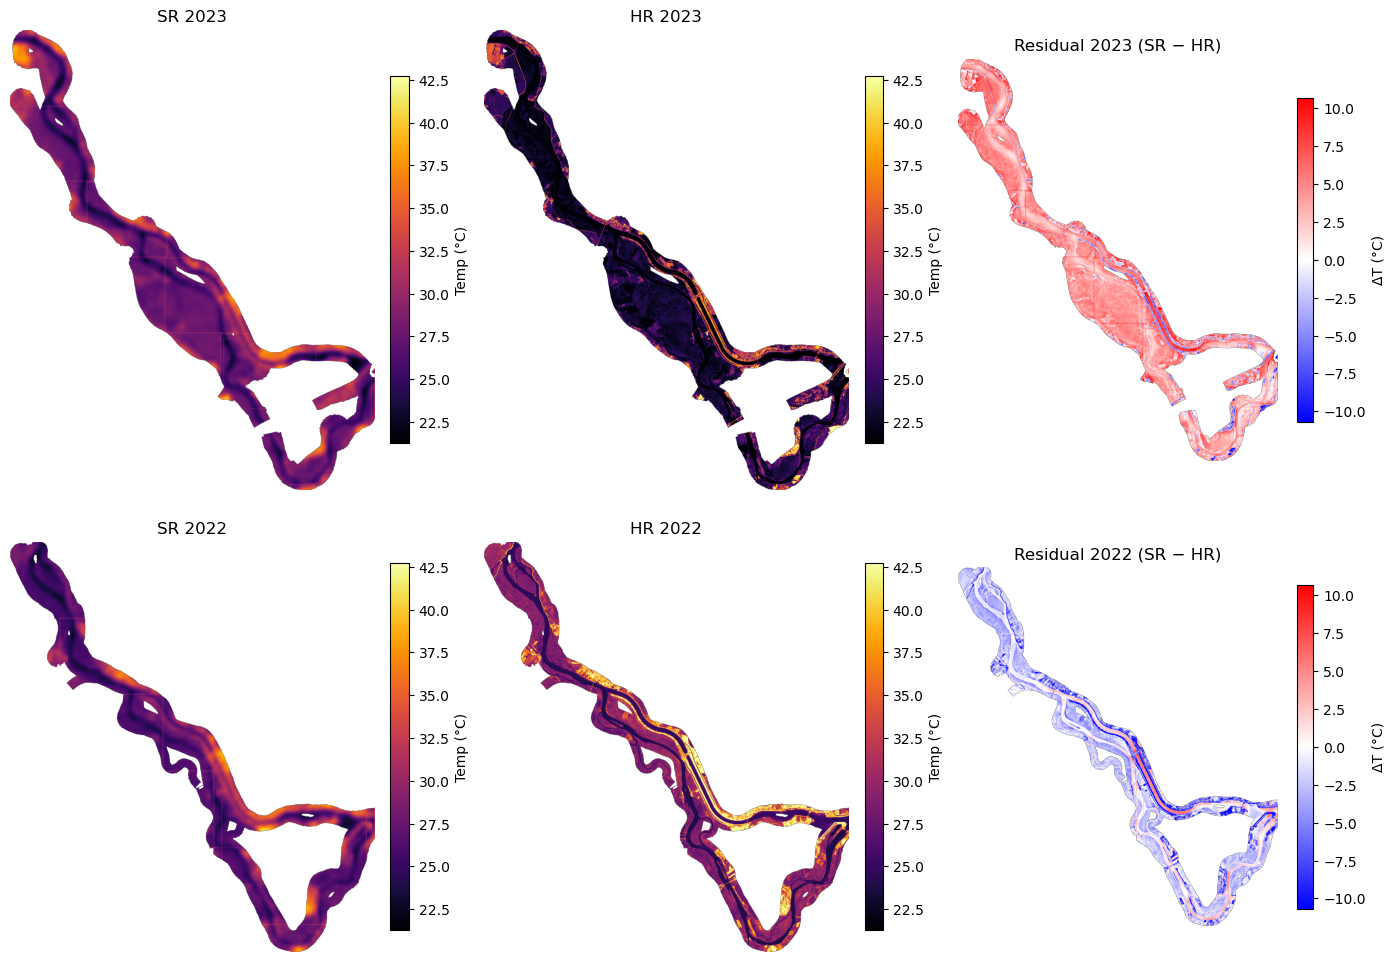

In [18]:
# Paths
sr_path1 = "results/SR_images/SR_BRC_2023.tif"
sr_path2 = "results/SR_images/SR_BRC_2022.tif"
hr_path1 = "results/SR_images/HR_reassembled_BRC_2023.tif"
hr_path2 = "results/SR_images/HR_reassembled_BRC_2022.tif"

# Helper function
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
    return np.where(arr == nodata, np.nan, arr)

# Load data
sr1 = load_raster(sr_path1)
hr1 = load_raster(hr_path1)
sr2 = load_raster(sr_path2)
hr2 = load_raster(hr_path2)

# Residuals (safe masking)
residual1 = np.where(np.isnan(sr1) | np.isnan(hr1), np.nan, sr1 - hr1)
residual2 = np.where(np.isnan(sr2) | np.isnan(hr2), np.nan, sr2 - hr2)

# Shared temperature scale (better comparison)
combined_hr = np.concatenate([hr1.flatten(), hr2.flatten()])
combined_hr = combined_hr[~np.isnan(combined_hr)]

vmin = np.percentile(combined_hr, 2)
vmax = np.percentile(combined_hr, 98)

# Dynamic residual scaling (symmetric)
res_all = np.concatenate([residual1.flatten(), residual2.flatten()])
res_all = res_all[~np.isnan(res_all)]
lim = np.percentile(np.abs(res_all), 98)

vmin_res, vmax_res = -lim, lim

# Print stats
print("BRC 2023:")
print(f"SR  range : {np.nanmin(sr1):.2f} – {np.nanmax(sr1):.2f} °C")
print(f"HR  range : {np.nanmin(hr1):.2f} – {np.nanmax(hr1):.2f} °C")

print("\nBRC 2022:")
print(f"SR  range : {np.nanmin(sr2):.2f} – {np.nanmax(sr2):.2f} °C")
print(f"HR  range : {np.nanmin(hr2):.2f} – {np.nanmax(hr2):.2f} °C")

print(f"\nShared vmin/vmax : {vmin:.2f} / {vmax:.2f}")
print(f"Residual limits  : {vmin_res:.2f} / {vmax_res:.2f}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# ---- 2023 ----
im0 = axes[0, 0].imshow(sr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("SR 2023")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(hr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("HR 2023")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(residual1, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[0, 2].set_title("Residual 2023 (SR − HR)")
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], label="ΔT (°C)", shrink=0.7)

# ---- 2022 ----
im3 = axes[1, 0].imshow(sr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("SR 2022")
axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(hr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("HR 2022")
axes[1, 1].axis("off")
plt.colorbar(im4, ax=axes[1, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(residual2, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[1, 2].set_title("Residual 2022 (SR − HR)")
axes[1, 2].axis("off")
plt.colorbar(im5, ax=axes[1, 2], label="ΔT (°C)", shrink=0.7)

plt.tight_layout()
plt.show()

In [22]:
plt.rcParams['figure.figsize'] = (16, 12)
%matplotlib inline

def plot_tir_sr_masked(lr, sr, hr, mask, mean, std, 
                       title="TIR Super-Resolution - River Strip", idx=None):
    """
    Correctly handles different shapes between LR and HR/SR
    """
    # Denormalize all to physical °C
    lr = (lr * std + mean).squeeze().cpu().numpy()
    sr = (sr * std + mean).squeeze().cpu().numpy()
    hr = (hr * std + mean).squeeze().cpu().numpy()
    
    # Mask comes from HR → shape (512, 512)
    mask_np = mask.squeeze().cpu().numpy().astype(bool)

    # Apply mask only to HR-sized images
    sr[~mask_np] = np.nan
    hr[~mask_np] = np.nan

    # For LR: we need to downscale the mask first (nearest neighbor)
    # Simple way: repeat the mask 4x and then downsample, but easier:
    from torch.nn.functional import avg_pool2d
    mask_lr = avg_pool2d(mask.unsqueeze(0), kernel_size=4, stride=4).squeeze().cpu().numpy() > 0.5
    lr[~mask_lr] = np.nan

    residual = sr - hr

    # Compute color range ONLY on valid HR pixels
    valid = ~np.isnan(hr)
    if valid.sum() == 0:
        print("Warning: No valid pixels in this patch!")
        return
    
    vmin = np.percentile(hr[valid], 1)
    vmax = np.percentile(hr[valid], 99)

    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    if idx is not None:
        fig.suptitle(f"{title} — Patch #{idx}", fontsize=16, fontweight='bold')
    else:
        fig.suptitle(title, fontsize=16, fontweight='bold')

    # LR
    im0 = axs[0,0].imshow(lr, cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0,0].set_title(f"LR (Low Resolution)\n{ lr.shape}")
    plt.colorbar(im0, ax=axs[0,0])

    # SR
    im1 = axs[0,1].imshow(sr, cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0,1].set_title(f"SR (Super-Resolved)\n{ sr.shape}")
    plt.colorbar(im1, ax=axs[0,1])

    # HR
    im2 = axs[1,0].imshow(hr, cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1,0].set_title(f"HR (Ground Truth)\n{ hr.shape}")
    plt.colorbar(im2, ax=axs[1,0])

    # Residual
    im3 = axs[1,1].imshow(residual, cmap='bwr', vmin=-3, vmax=3)
    axs[1,1].set_title("Residual (SR - HR) [°C]")
    plt.colorbar(im3, ax=axs[1,1])

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

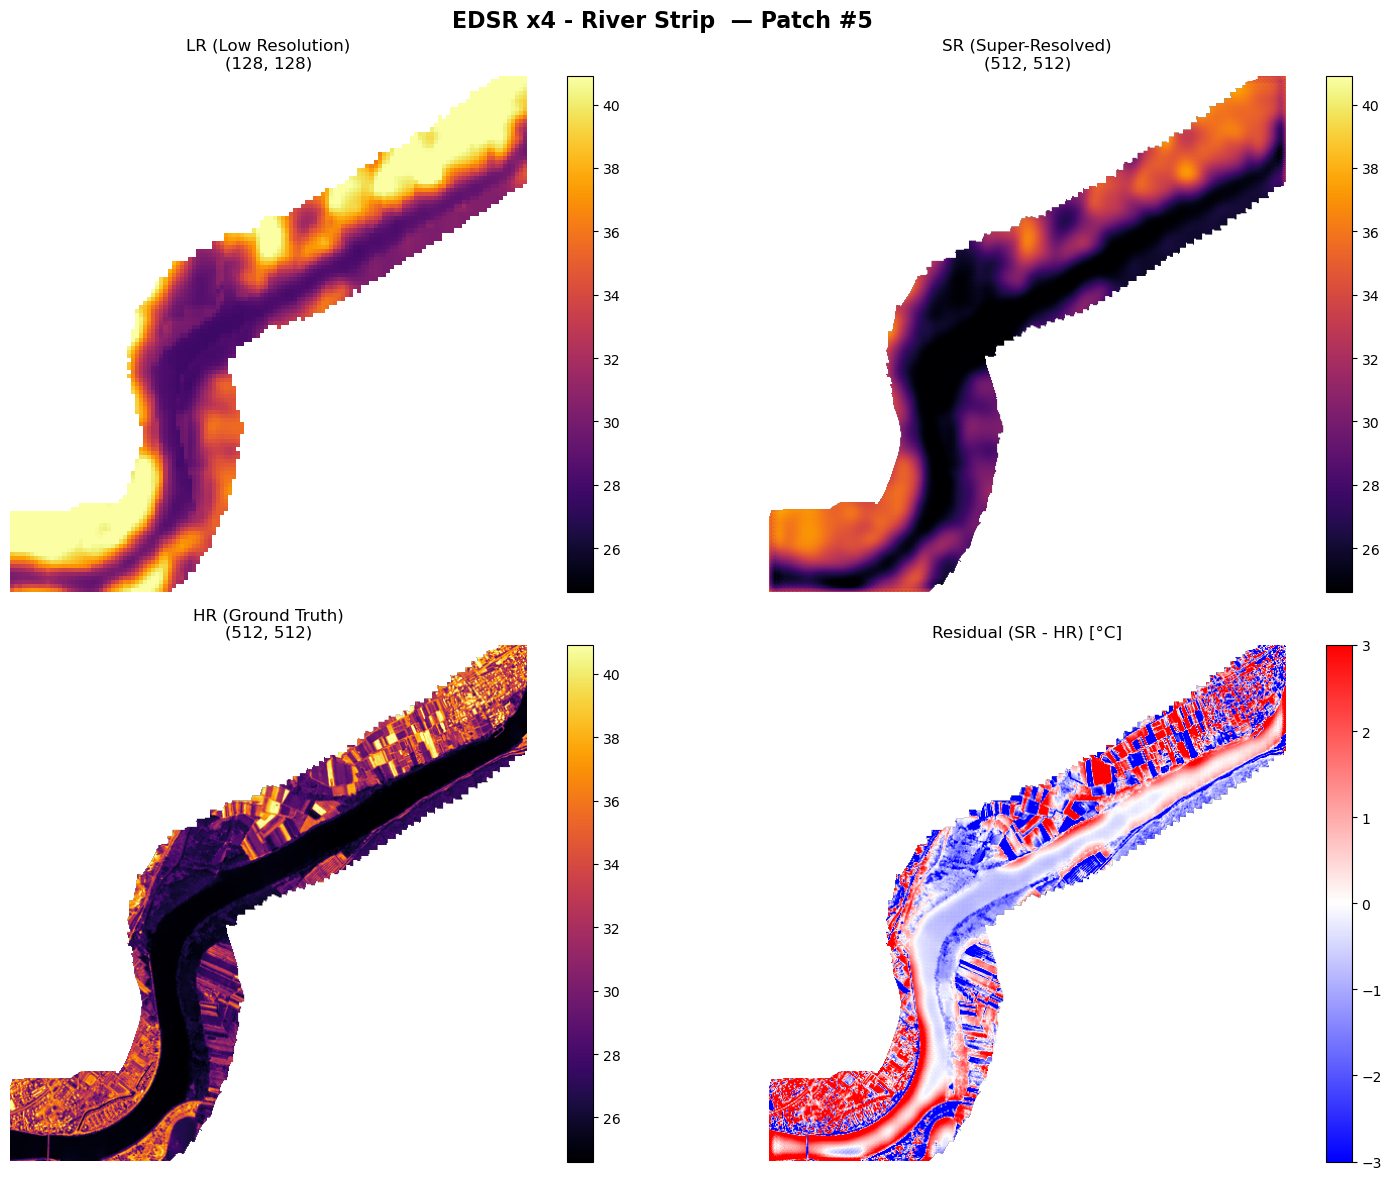

In [23]:
idx = 5   # change this to explore different patches

lr_t, hr_t, mask_t = ds[idx]

lr_input = lr_t.unsqueeze(0).to(device)

with torch.no_grad():
    sr_t = model(lr_input)

# Now plot with masking
plot_tir_sr_masked(
    lr=lr_t,
    sr=sr_t,
    hr=hr_t,
    mask=mask_t,
    mean=model.hparams.mean,
    std=model.hparams.std,
    title="EDSR x4 - River Strip ",
    idx=idx
)

In [5]:
# Quick sanity check — run this on your full metadata
import rasterio
import numpy as np

with open("data/full_metadata.json") as f:
    metadata = pd.DataFrame(json.load(f))

all_vals = []
for _, row in metadata.iterrows():
    with rasterio.open(row["hr_path"]) as src:
        hr = src.read(1).astype(np.float32)
        nodata = src.nodata
        valid = hr[hr != nodata] if nodata else hr[~np.isnan(hr)]
        all_vals.append(valid)

all_vals = np.concatenate(all_vals)
print(f"Dataset min: {all_vals.min():.1f}°C")
print(f"Dataset max: {all_vals.max():.1f}°C") 
print(f"1st percentile:  {np.percentile(all_vals, 1):.1f}°C")
print(f"99th percentile: {np.percentile(all_vals, 99):.1f}°C")

Dataset min: 1.2°C
Dataset max: 131.2°C
1st percentile:  21.3°C
99th percentile: 43.5°C


In [6]:
outlier_patches = []
for _, row in metadata.iterrows():
    with rasterio.open(row["hr_path"]) as src:
        hr = src.read(1).astype(np.float32)
        nodata = src.nodata
        valid = hr[hr != nodata] if nodata else hr[~np.isnan(hr)]
        if valid.size > 0 and valid.max() > 80:
            outlier_patches.append({
                "path": row["hr_path"],
                "max": valid.max(),
                "min": valid.min(),
                "mean": valid.mean()
            })

for p in outlier_patches:
    print(p)

{'path': '/share/castor/home/e2406751/Superresolution-TIR/data/processed/tir_patches/HR/BRC_2023_6.tif', 'max': np.float32(131.16948), 'min': np.float32(1.2212056), 'mean': np.float32(25.511024)}
